# IC -> Residual Pipeline

Learns to predict the small-scale residual `N-body - best-fit` from the initial conditions,
then evaluates the combined (`best-fit + IC2RES`) result against N-body.

In [1]:
print('Loading libraries and setting up environment...')

import sys, os
from pathlib import Path

# Make imports robust to notebook working directory.
# This notebook lives in .../DDDF/src, so we add both src and repo root.
nb_dir = Path.cwd()
if not (nb_dir / 'config.py').exists() and (nb_dir / 'src' / 'config.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import importlib
import torch
import dddf
from model.gen_patches import extract_patches
import model.model as nnmodel
import model.train_model as train_module

import config as cfg
import pipeline as _pipeline_module
from pipeline import load_snapshot_pair, compute_target_psi_div, free_gpu_memory, compute_best_fit

import importlib
importlib.reload(cfg)

# ── User settings ─────────────────────────────────────────────────
N_p        = cfg.N_p
data_dir   = cfg.data_dir
model_dir  = cfg.model_dir
# ──────────────────────────────────────────────────────────────────

# ── Derived constants ──────────────────────────────────────────────
L         = cfg.L
boxsize   = cfg.boxsize
MAS       = cfg.MAS
threads   = cfg.threads
grid_size = N_p

dl        = dddf.DDDF(cfg.init_redshift(N_p), cfg.final_snapshot_z, cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, data_dir={data_dir}, model_dir={model_dir}')

Loading libraries and setting up environment...
hostname: nid001021
N_p=256, boxsize=1000.0, data_dir=tophat0.4, model_dir=tophat0.4v2


## 1. Training: IC -> Residual

In [2]:
patch_size = cfg.patch_size
padding    = cfg.padding
overlap    = cfg.overlap
rotate     = cfg.rotate

# ── Section settings ──────────────────────────────────────────────
train_realizations = cfg.train_realizations   # e.g. list(range(16)); edit in config.py
coef_file   = cfg.best_fit_avg_coef_path(data_dir, cfg.L, N_p)  # None -> refit from scratch
# ──────────────────────────────────────────────────────────────────

train_path = cfg.training_data_path(train_realizations, patch_size, padding, overlap, rotate, N_p, data_dir=data_dir)

if os.path.exists(train_path):
    cached = np.load(train_path)
    input_patches  = cached['input_patches']
    target_patches = cached['target_patches']
    print(f'Combined training data already exists, loaded: {train_path}')
    print(f'{input_patches.shape[0]} patch pairs, shape {input_patches.shape[1:]}')
else:
    all_input_patches  = []
    all_target_patches = []

    for r in train_realizations:
        train_path_r = cfg.training_data_path(r, patch_size, padding, overlap, rotate, N_p, data_dir=data_dir)
        if os.path.exists(train_path_r):
            cached = np.load(train_path_r)
            inp_r = cached['input_patches']
            tgt_r = cached['target_patches']
            print(f'  [r{r}] training file exists, loaded: {train_path_r}')
        else:
            snap_info_r = load_snapshot_pair(
                dl,
                cfg.snapshot_paths(r, N_p),
                cfg.snapshot_format(N_p),
                boxsize, grid_size,
            )
            tgt_psi_div_r = compute_target_psi_div(dl, snap_info_r, N_p, boxsize, veck_main)
            bf_psi_div_r, _, _ = compute_best_fit(
                dl, snap_info_r[0]['delta'], tgt_psi_div_r,
                snap_info_r[0]['pos'], snap_info_r[1]['delta'],
                veck_main, N_p, boxsize, MAS,
                r, data_dir, L,
                coef_file=coef_file,
                overwrite=False,
            )
            residual_r = tgt_psi_div_r - bf_psi_div_r
            print(f'  [r{r}] residual χ² = {np.mean(residual_r**2):.6e}')

            inp_r = extract_patches(snap_info_r[0]['delta'], patch_size, padding, overlap, rotate)
            tgt_r = extract_patches(residual_r,              patch_size, padding, overlap, rotate)

            os.makedirs(os.path.dirname(train_path_r), exist_ok=True)
            np.savez(
                train_path_r,
                input_patches=inp_r,
                target_patches=tgt_r,
                patch_size=patch_size,
                padding=padding,
                overlap=overlap,
                realization=r,
            )
            print(f'  [r{r}] saved: {train_path_r}')
            del snap_info_r, tgt_psi_div_r, bf_psi_div_r, residual_r

        all_input_patches.append(inp_r)
        all_target_patches.append(tgt_r)

    input_patches  = np.concatenate(all_input_patches,  axis=0)
    target_patches = np.concatenate(all_target_patches, axis=0)
    assert input_patches.shape == target_patches.shape
    print(f'{input_patches.shape[0]} patch pairs from {len(train_realizations)} realization(s), shape {input_patches.shape[1:]}')

    np.savez(train_path, input_patches=input_patches, target_patches=target_patches,
             patch_size=patch_size, padding=padding, overlap=overlap)
    print(f'combined training data saved: {train_path}')

Combined training data already exists, loaded: /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4/training-data-IC2RES-N256PS20P2O00RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15.npz
351520 patch pairs, shape (24, 24, 24)


In [3]:
free_gpu_memory()

importlib.reload(cfg)

# ── Section settings ──────────────────────────────────────────────
overwrite_train = False   # True -> force retrain; False -> skip if model exists.
# ──────────────────────────────────────────────────────────────────

model_name = cfg.gan_model_name(train_realizations, patch_size, padding, rotate, N_p, model_dir=model_dir)
train_module.train_gan(
    training_data_path=train_path,
    save_file_name=model_name,
    batch_size=cfg.batch_size,
    epochs=cfg.epochs,
    lr_g=cfg.gan_lr_g,
    lr_d=cfg.gan_lr_d,
    lambda_pixel=cfg.gan_lambda_pixel,
    n_disc_layers=cfg.gan_n_disc_layers,
    lambda_fm=cfg.gan_lambda_fm,
    lambda_gp=cfg.gan_lambda_gp,
    d_update_interval=cfg.gan_d_update_interval,
    use_spectral_norm=cfg.gan_use_spectral_norm,
    checkpoint_interval=cfg.checkpoint_interval,
    resume_checkpoint='auto',
    overwrite=overwrite_train,
 )

GPU memory in use: 0.00 GB
Model already exists, skipping training: /pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v2/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e55.pth


/global/u1/l/liuyh15/WorkSpace/DDDF/.venv/lib/python3.11/site-packages/torch/__init__.py:1146: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


## 2. Verification

Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4/best-fitL1N256-0.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v2/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e55.pth (pools=4, device=cuda)


apply_model (z-slices): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:07<00:00,  1.75it/s]


apply_model done: step=20, elapsed=7.6s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


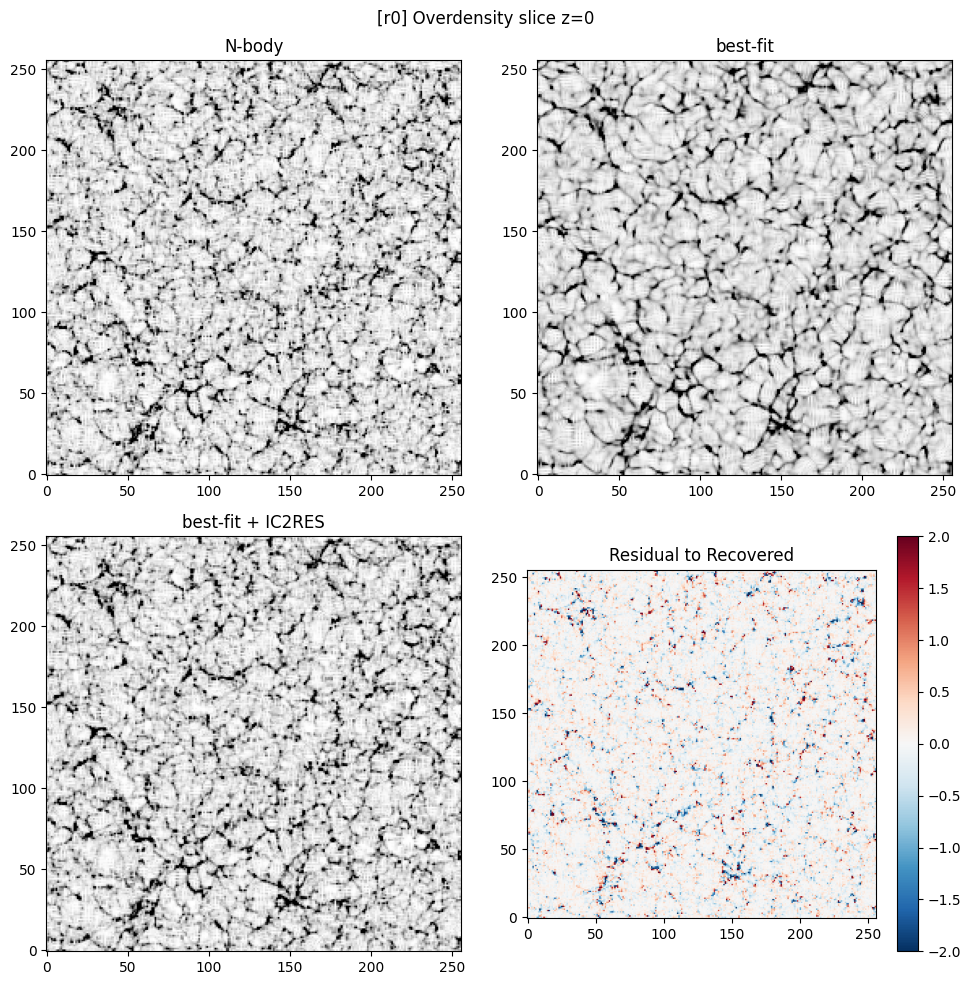

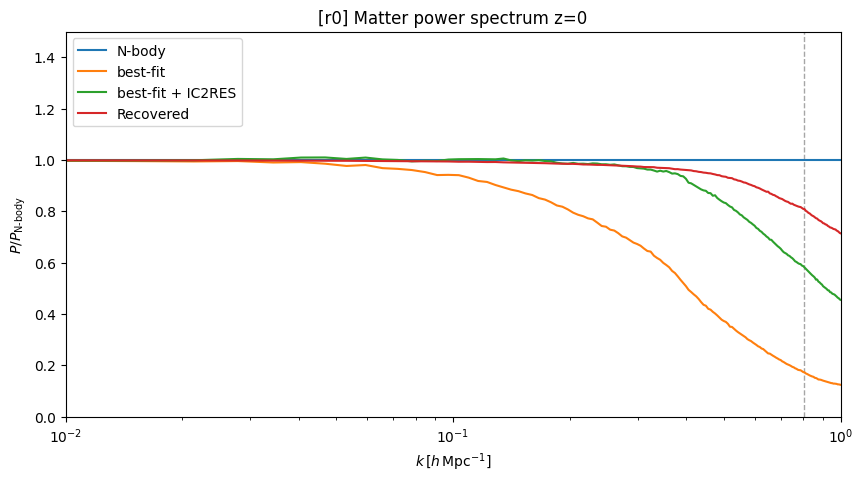


Computing bispectrum of the field...
Time to compute bispectrum = 5.41

Computing bispectrum of the field...
Time to compute bispectrum = 5.38

Computing bispectrum of the field...
Time to compute bispectrum = 5.43

Computing bispectrum of the field...
Time to compute bispectrum = 5.43


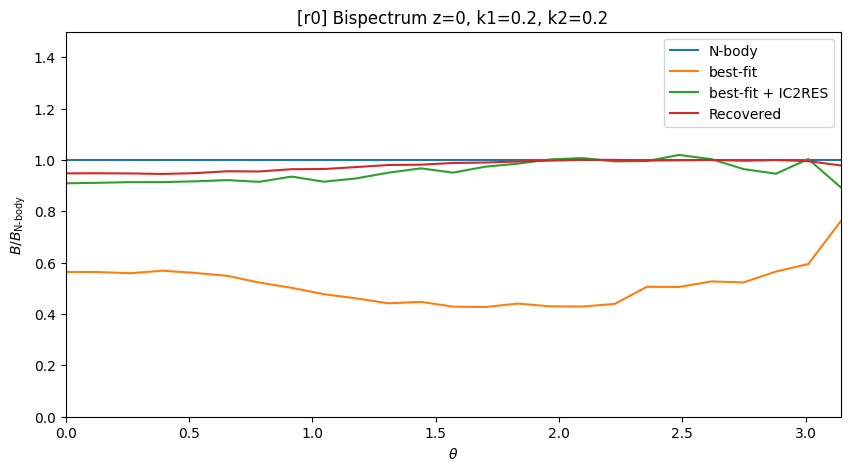

[r0] best-fit chi^2 (k<=0.3) = 3.097623e-02
[r0] best-fit + IC2RES chi^2 (k<=0.3) = 1.672456e-04
[r0] Recovered chi^2 (k<=0.3) = 2.007697e-04
Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4/best-fitL1N256-19.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v2/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e55.pth (pools=4, device=cuda)


apply_model (z-slices): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:06<00:00,  2.07it/s]


apply_model done: step=20, elapsed=6.8s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


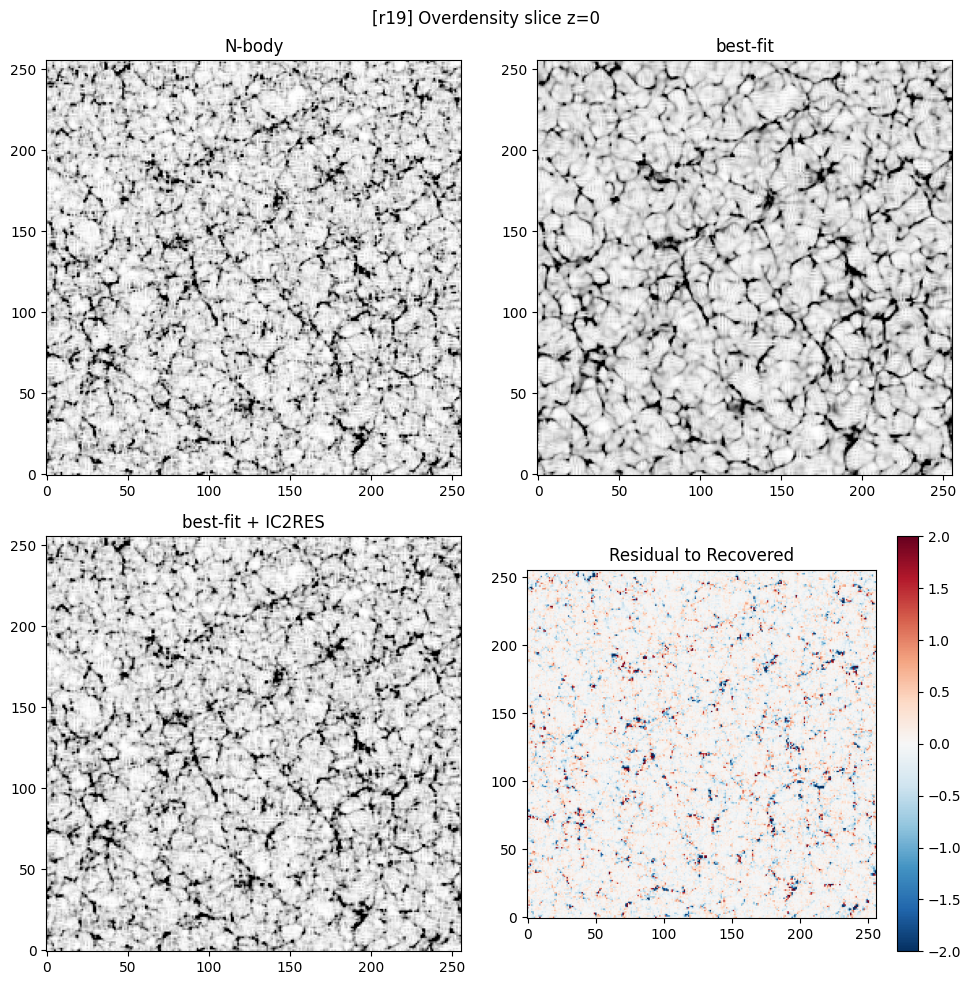

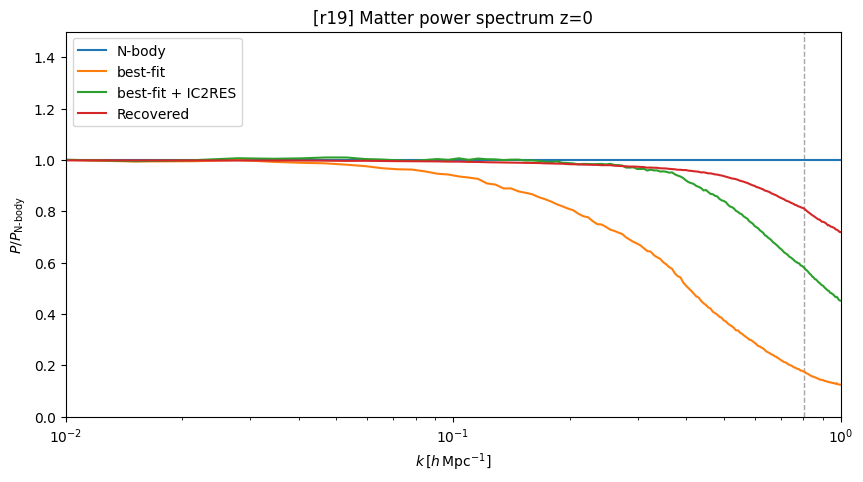


Computing bispectrum of the field...
Time to compute bispectrum = 5.21

Computing bispectrum of the field...
Time to compute bispectrum = 5.23

Computing bispectrum of the field...
Time to compute bispectrum = 5.22

Computing bispectrum of the field...
Time to compute bispectrum = 5.23


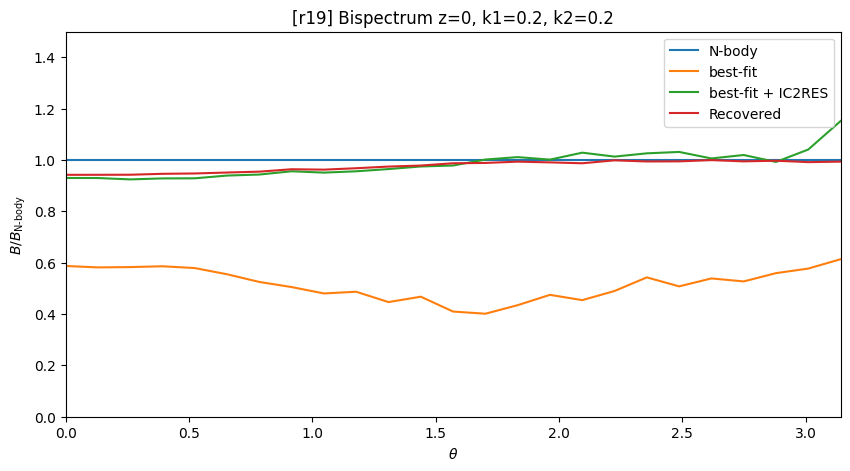

[r19] best-fit chi^2 (k<=0.3) = 3.047049e-02
[r19] best-fit + IC2RES chi^2 (k<=0.3) = 1.801139e-04
[r19] Recovered chi^2 (k<=0.3) = 2.176910e-04


{'realization': 19,
 'checkpoint': '/pscratch/sd/l/liuyh15/DDDF/models/tophat0.4v2/gan-IC2RES-N256PS20P2RotateTrue-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e55.pth',
 'chi2': {'best-fit': 0.030470492430249095,
  'best-fit + IC2RES': 0.00018011391602078294,
  'Recovered': 0.00021769096050187672},
 'labels': ['N-body', 'best-fit', 'best-fit + IC2RES', 'Recovered']}

In [4]:
from verify import verify_realization

verify_realization(realization=0)
verify_realization(realization=19)